In [ ]:
%pip install arm-pyart s3fs
import gzip, io
import fsspec, pyart
import matplotlib.pyplot as plt

# --- 1. connect to the public NEXRAD archive (anonymous) ---
fs = fsspec.filesystem("s3", anon=True)
folder = "unidata-nexrad-level2/2013/09/12/KFTG/"

# --- 2. (optional) browse the folder to pick a ~05 UTC volume ---
for f in fs.ls(folder):
    print(f.split("/")[-1])


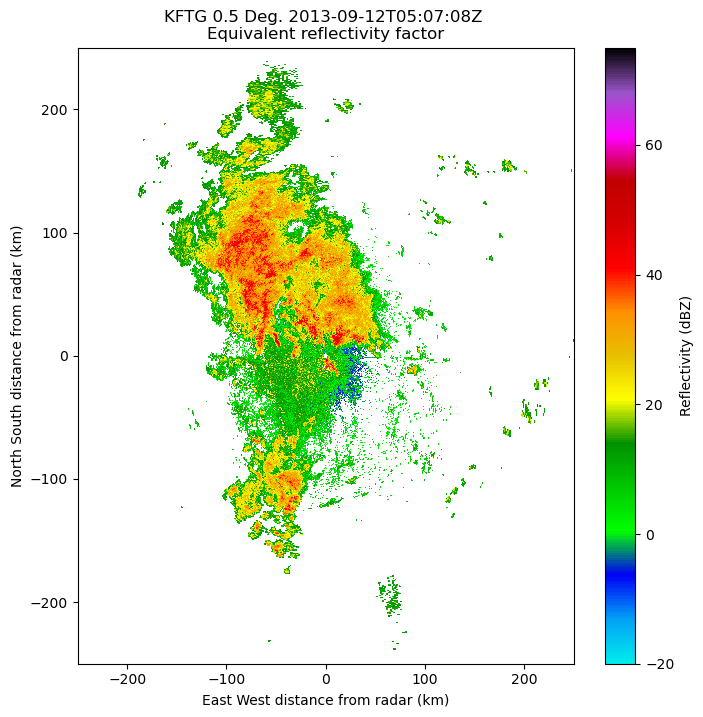

In [3]:
# --- 3. read one volume, unzipping the outer gzip ourselves ---
key = folder + "KFTG20130912_050708_V06.gz"   # <- set to your chosen file
with fs.open(key, "rb") as fh:
    raw = fh.read()
if raw[:2] == b"\x1f\x8b":                     # gzip magic bytes
    raw = gzip.decompress(raw)
radar = pyart.io.read_nexrad_archive(io.BytesIO(raw))

# --- 4. plot the 0.5° reflectivity PPI out to ~230 km ---
disp = pyart.graph.RadarDisplay(radar)
fig = plt.figure(figsize=(8, 8))
disp.plot("reflectivity", sweep=0,
          vmin=-20, vmax=75,
          cmap="NWSRef",
          colorbar_label="Reflectivity (dBZ)")
disp.set_limits(xlim=(-250, 250), ylim=(-250, 250))

# --- 5. save for embedding in the notebook ---
plt.savefig("block2_image1.png", dpi=130, bbox_inches="tight")
plt.show()